## import libraries and data

In [10]:
from locale import normalize

%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from src.extraction import load_processed, FEATURE_COLUMNS
from src.classification import build_X_y, split_data, analyze_imbalance, train_model,evaluate_models, plot_all_confusion_matrices, plot_f1_comparison
from sklearn.metrics import classification_report

df_clean_clusters = load_processed("df_clean_with_target.csv")
df_clean_clusters = df_clean_clusters[FEATURE_COLUMNS + ["target"]]

df_clean_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,target
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,Clients à Faible Activité
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,Clients à Risque
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,Clients Premium
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,Clients à Faible Activité
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,Clients à Faible Activité
...,...,...,...,...,...,...,...,...
8944,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,Clients à Faible Activité
8945,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,Clients à Faible Activité
8946,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,Clients à Faible Activité
8947,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,Clients à Faible Activité


## Build X / y and stratified train/test split

In [11]:
X, y = build_X_y(df_clean_clusters)

X_train, X_test, y_train, y_test = split_data(X, y)

# check if the Stratification have the same proportions
display(pd.DataFrame({
    "train" : y_train.value_counts(normalize=True),
    "test"  : y_test.value_counts(normalize=True)
}))

,train,test
target,,
Clients Premium,0.399078,0.398883
Clients à Faible Activité,0.333706,0.334078
Clients à Risque,0.267216,0.267039


## Class imbalance analysis

In [12]:
table, ratio, needs_resampling = analyze_imbalance(y_train)
display(table)
print(f"Imbalance ratio (largest / smallest): {ratio}")
print("Resampling needed:", needs_resampling)

SAMPLING = "over" if needs_resampling else "none"
print("Sampling strategy used in the pipeline:", SAMPLING)

,count,pct
target,,
Clients Premium,2857,39.9
Clients à Faible Activité,2389,33.4
Clients à Risque,1913,26.7


Imbalance ratio (largest / smallest): 1.49
Resampling needed: False
Sampling strategy used in the pipeline: none


## Training the 4 pipelines

In [13]:
pipelines, train_times = train_model(X_train, y_train, sampling=SAMPLING)

display(train_times)

for name, pipeline in pipelines.items():
    print(f"{name} test accuracy = {pipeline.score(X_test, y_test):.3f}")

pipelines["svm"]

,train_time_s
model,
random_forest,0.653
svm,3.584
decision_tree,0.058
logistic_regression,0.077


random_forest test accuracy = 0.974
svm test accuracy = 0.909
decision_tree test accuracy = 0.953
logistic_regression test accuracy = 0.904


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['Clients Premium','Clients à Faible Activité','Clients à Risque']"
feature_names_in_,"ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation on the test set,

In [14]:
comparison = evaluate_models(pipelines, X_test, y_test, train_times)
display(comparison)

for name, pipeline in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipeline.predict(X_test), digits=3))

,accuracy,precision_macro,recall_macro,f1_macro,train_time_s
model,,,,,
random_forest,0.9743,0.9748,0.9744,0.9746,0.653
decision_tree,0.9531,0.9535,0.9530,0.9533,0.058
svm,0.9089,0.9065,0.9099,0.9080,3.584
logistic_regression,0.9039,0.9036,0.9053,0.9044,0.077


===== random_forest =====
                           precision    recall  f1-score   support

          Clients Premium      0.969     0.978     0.974       714
Clients à Faible Activité      0.978     0.967     0.972       598
         Clients à Risque      0.977     0.979     0.978       478

                 accuracy                          0.974      1790
                macro avg      0.975     0.974     0.975      1790
             weighted avg      0.974     0.974     0.974      1790

===== svm =====
                           precision    recall  f1-score   support

          Clients Premium      0.929     0.915     0.922       714
Clients à Faible Activité      0.904     0.886     0.895       598
         Clients à Risque      0.886     0.929     0.907       478

                 accuracy                          0.909      1790
                macro avg      0.907     0.910     0.908      1790
             weighted avg      0.909     0.909     0.909      1790

===== decision

In [ ]:
##

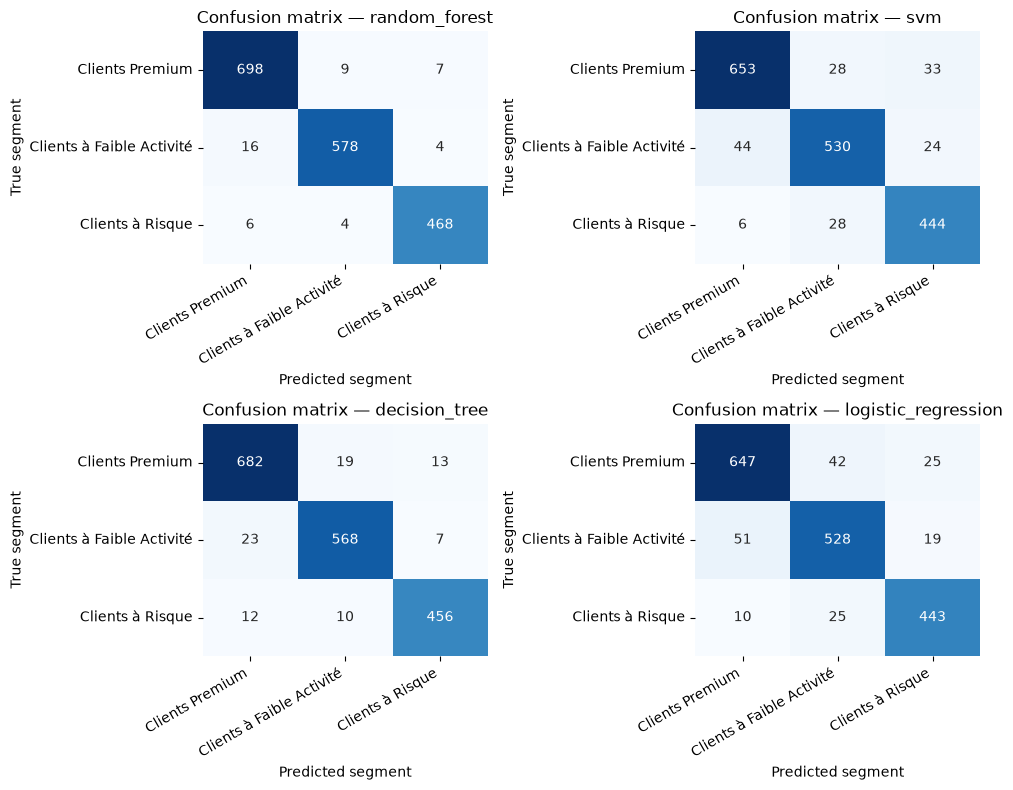

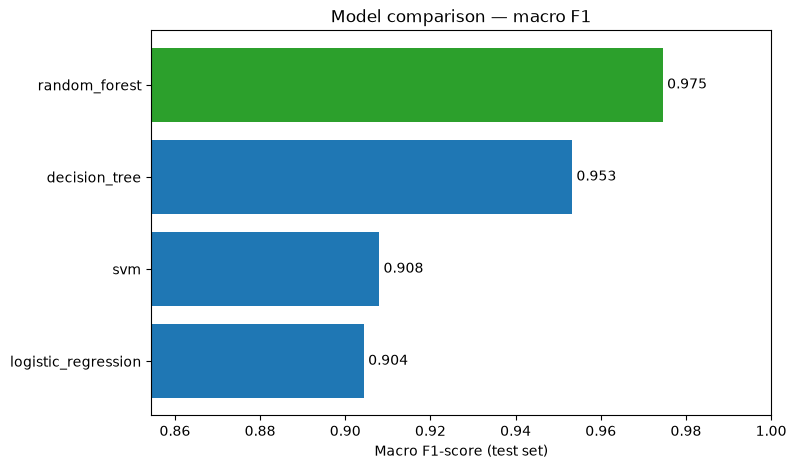

In [18]:
plot_all_confusion_matrices(pipelines, X_test, y_test)
plt.show()

plot_f1_comparison(comparison)
plt.show()